# Multi-Provider Evaluation Overview

This notebook reads normalized fact-check artifacts from `../results/live/`, computes summary tables, and visualizes provider quality, latency, and error patterns.

In [26]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
RESULTS_DIR = Path('../results/live')
SUMMARY_DIR = RESULTS_DIR / 'summary'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


In [27]:
def load_artifacts(results_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(results_dir.rglob('*.json')):
        if 'summary' in path.parts:
            continue
        payload = json.loads(path.read_text())
        if isinstance(payload, list):
            rows.extend(payload)
        else:
            rows.append(payload)
    return pd.DataFrame(rows)

raw = load_artifacts(RESULTS_DIR)
raw.head(2)


,id,timestamp,claim,provider,provider_mode,research_endpoint,retrieved_contexts,response,citations,reference_answer,reference_verdict,topic,freshness_bucket,latency_ms,status,error_type,cost_estimate
0,benchmark_20260502T171651Z_claim_moon_01_tavil...,2026-05-02T17:17:08.341023+00:00,"{'id': 'claim_moon_01', 'text': 'The Moon land...",tavily,tavily_research,POST/GET https://api.tavily.com/research,[Apollo 11 - Featured Documents - National Arc...,"{'verdict': 'SUPPORTED', 'summary': 'The first...",[{'title': 'Apollo 11 - Featured Documents - N...,"Apollo 11 landed on the Moon on July 20, 1969.",SUPPORTED,history,evergreen,16421,success,None,None
1,benchmark_20260502T171651Z_claim_moon_01_exa_e...,2026-05-02T17:17:08.470777+00:00,"{'id': 'claim_moon_01', 'text': 'The Moon land...",exa,exa_search_structured,None,[],"{'verdict': 'INSUFFICIENT_EVIDENCE', 'summary'...",[],"Apollo 11 landed on the Moon on July 20, 1969.",SUPPORTED,history,evergreen,0,error,BenchmarkError,None


In [28]:
if raw.empty:
    raise ValueError('No artifacts found under eval/results/live')

df = raw.copy()
df['claim_text'] = df['claim'].apply(lambda value: value.get('text', ''))
df['reference_verdict'] = df['reference_verdict'].fillna('')
df['response_verdict'] = df['response'].apply(lambda value: (value or {}).get('verdict', ''))
df['response_explanation'] = df['response'].apply(lambda value: (value or {}).get('explanation', ''))
df['response_confidence'] = df['response'].apply(lambda value: (value or {}).get('confidence', np.nan))
df['latency_ms'] = pd.to_numeric(df['latency_ms'], errors='coerce').fillna(0)
df['cost_estimate'] = pd.to_numeric(df['cost_estimate'], errors='coerce').fillna(0)
df['retrieved_contexts'] = df['retrieved_contexts'].apply(lambda value: value if isinstance(value, list) else [])
df['citations'] = df['citations'].apply(lambda value: value if isinstance(value, list) else [])
df['citation_count'] = df['citations'].apply(len)
df['source_count'] = df['citations'].apply(lambda items: len({item.get('url', '') for item in items if isinstance(item, dict)}))
df['status'] = df['status'].fillna('success')

ragas_path = SUMMARY_DIR / 'ragas_scores.csv'
ragas_scores = pd.read_csv(ragas_path) if ragas_path.exists() else pd.DataFrame()
provider_summary = (
    df.groupby(['provider', 'provider_mode'], dropna=False)
      .agg(
          runs=('id', 'count'),
          success_rate=('status', lambda values: (values == 'success').mean()),
          mean_latency_ms=('latency_ms', 'mean'),
          mean_cost=('cost_estimate', 'mean'),
          mean_citations=('citation_count', 'mean'),
          verdict_accuracy=('response_verdict', lambda values: (values.reset_index(drop=True) == df.loc[values.index, 'reference_verdict'].reset_index(drop=True)).mean())
      )
      .reset_index()
)
provider_summary.to_csv(SUMMARY_DIR / 'provider_summary_from_notebook.csv', index=False)
provider_summary


,provider,provider_mode,runs,success_rate,mean_latency_ms,mean_cost,mean_citations,verdict_accuracy
0,brave,brave_answers_native,6,0.0,0.000000,0.0,0.000000,0.166667
1,brave,brave_context_plus_judge,6,1.0,3920.833333,0.0,6.666667,0.666667
2,exa,exa_research_async,6,0.0,0.000000,0.0,0.000000,0.166667
3,exa,exa_search_structured,6,0.0,0.000000,0.0,0.000000,0.166667
4,firecrawl,firecrawl_search_plus_judge,6,1.0,25530.666667,0.0,0.000000,0.833333
5,parallel,parallel_task_run,6,0.0,0.000000,0.0,0.000000,0.166667
6,tavily,tavily_research,6,1.0,16470.666667,0.0,4.666667,0.500000


## Dataset Summary

In [29]:
display(df[['provider', 'provider_mode', 'status', 'latency_ms', 'citation_count', 'source_count']].head(10))
display(provider_summary)


,provider,provider_mode,status,latency_ms,citation_count,source_count
0,tavily,tavily_research,success,16421,5,5
1,exa,exa_search_structured,error,0,0,0
2,exa,exa_research_async,error,0,0,0
3,brave,brave_context_plus_judge,success,3920,7,7
4,brave,brave_answers_native,error,0,0,0
5,firecrawl,firecrawl_search_plus_judge,success,63526,0,0
6,parallel,parallel_task_run,error,0,0,0
7,tavily,tavily_research,success,13310,5,5
8,exa,exa_search_structured,error,0,0,0
9,exa,exa_research_async,error,0,0,0


,provider,provider_mode,runs,success_rate,mean_latency_ms,mean_cost,mean_citations,verdict_accuracy
0,brave,brave_answers_native,6,0.0,0.000000,0.0,0.000000,0.166667
1,brave,brave_context_plus_judge,6,1.0,3920.833333,0.0,6.666667,0.666667
2,exa,exa_research_async,6,0.0,0.000000,0.0,0.000000,0.166667
3,exa,exa_search_structured,6,0.0,0.000000,0.0,0.000000,0.166667
4,firecrawl,firecrawl_search_plus_judge,6,1.0,25530.666667,0.0,0.000000,0.833333
5,parallel,parallel_task_run,6,0.0,0.000000,0.0,0.000000,0.166667
6,tavily,tavily_research,6,1.0,16470.666667,0.0,4.666667,0.500000


## Coverage And Failure Rate

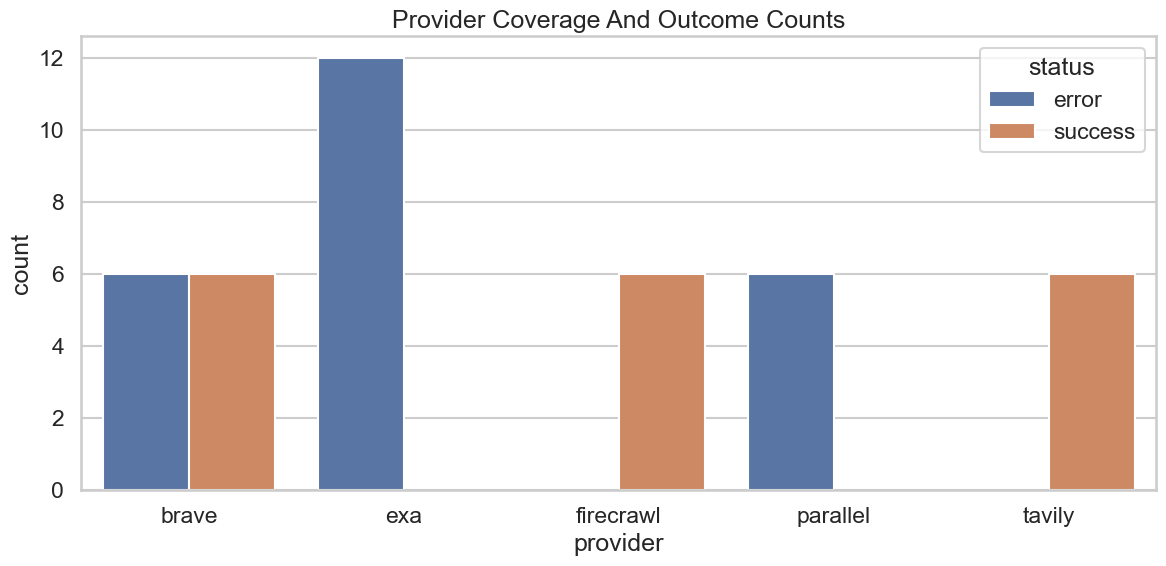

In [30]:
coverage = df.groupby(['provider', 'status']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=coverage, x='provider', y='count', hue='status')
plt.title('Provider Coverage And Outcome Counts')
plt.tight_layout()
plt.show()


## Latency Distribution

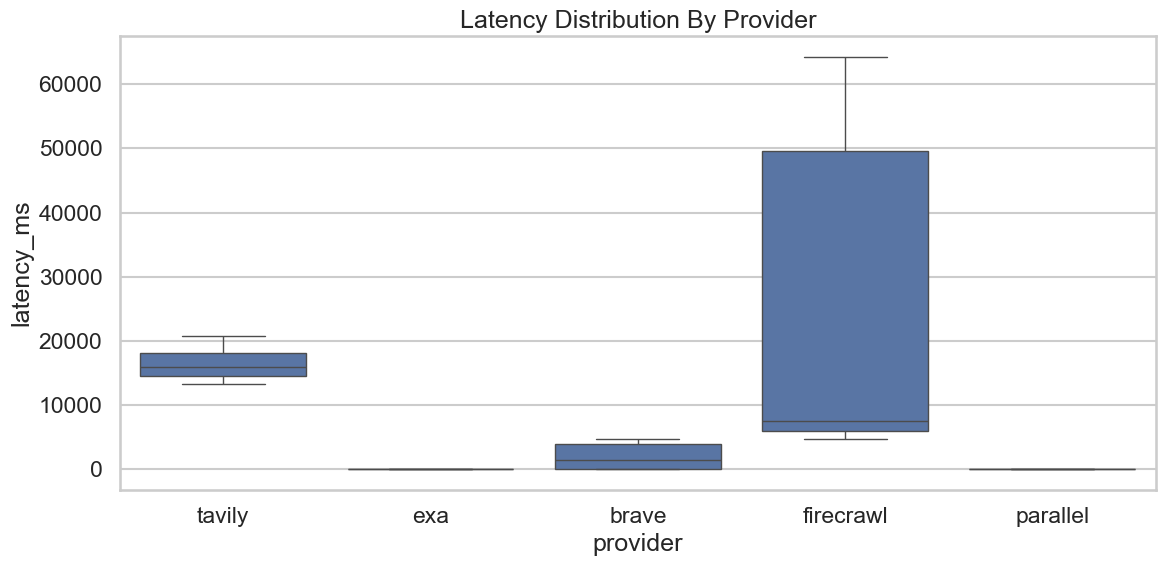

In [31]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='provider', y='latency_ms')
plt.title('Latency Distribution By Provider')
plt.tight_layout()
plt.show()


## Cost Estimate Comparison

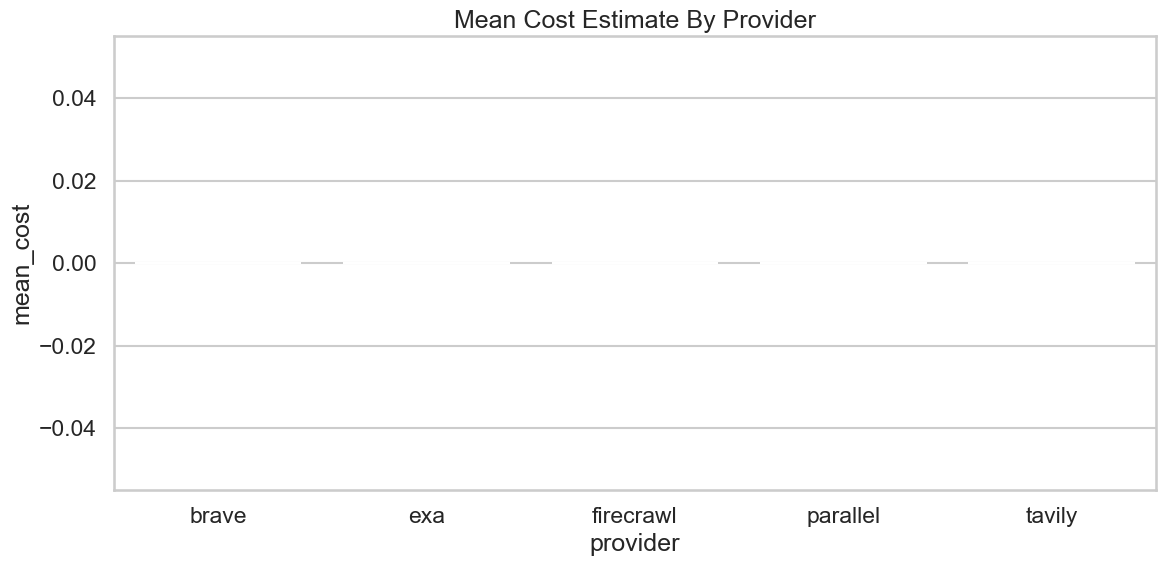

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(data=provider_summary, x='provider', y='mean_cost')
plt.title('Mean Cost Estimate By Provider')
plt.tight_layout()
plt.show()


## Ragas Metrics

In [33]:
if ragas_scores.empty:
    print('No ragas_scores.csv found. Run eval/src/evaluate_results.py --run-ragas to populate it.')
else:
    ragas_numeric = ragas_scores.select_dtypes(include=['number']).copy()
    ragas_numeric['provider'] = ragas_scores['provider']
    ragas_means = ragas_numeric.groupby('provider').mean(numeric_only=True).reset_index()
    melted = ragas_means.melt(id_vars='provider', var_name='metric', value_name='score')
    plt.figure(figsize=(14, 6))
    sns.barplot(data=melted, x='provider', y='score', hue='metric')
    plt.title('Mean Ragas Metrics By Provider')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 6))
    ragas_long = ragas_scores.melt(id_vars=['provider', 'provider_mode', 'artifact_id'], var_name='metric', value_name='score')
    ragas_long = ragas_long[ragas_long['metric'].isin(['context_precision', 'faithfulness', 'response_relevancy'])]
    sns.boxplot(data=ragas_long, x='metric', y='score', hue='provider')
    plt.title('Ragas Metric Spread')
    plt.tight_layout()
    plt.show()


No ragas_scores.csv found. Run eval/src/evaluate_results.py --run-ragas to populate it.


## Verdict Confusion Matrix

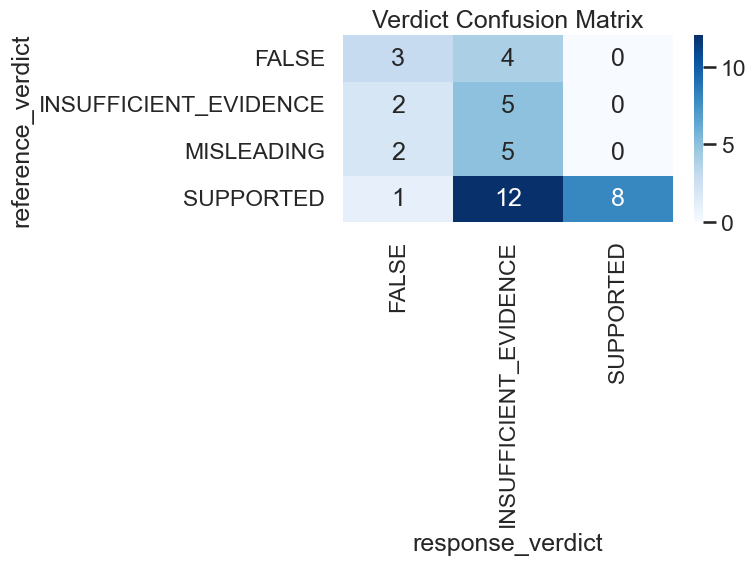

In [34]:
confusion = pd.crosstab(df['reference_verdict'], df['response_verdict'])
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Verdict Confusion Matrix')
plt.tight_layout()
plt.show()


## Latency vs Faithfulness

In [35]:
if ragas_scores.empty or 'faithfulness' not in ragas_scores.columns:
    print('Faithfulness scores are not available yet.')
else:
    merged = df.merge(ragas_scores[['artifact_id', 'faithfulness']], left_on='id', right_on='artifact_id', how='left')
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=merged, x='latency_ms', y='faithfulness', hue='provider', s=120)
    plt.title('Latency vs Faithfulness')
    plt.tight_layout()
    plt.show()


Faithfulness scores are not available yet.


## Citation Volume

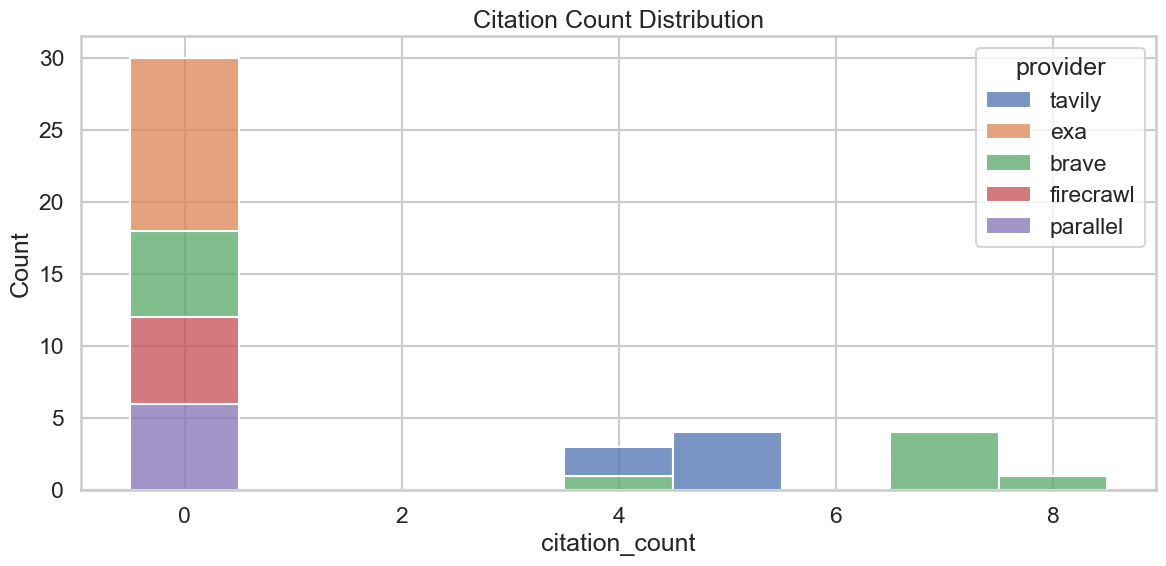

In [36]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='citation_count', hue='provider', multiple='stack', discrete=True)
plt.title('Citation Count Distribution')
plt.tight_layout()
plt.show()


## Worst Samples

In [37]:
worst = df.sort_values(['status', 'latency_ms'], ascending=[True, False])[['id', 'provider', 'provider_mode', 'status', 'response_verdict', 'reference_verdict', 'latency_ms', 'claim_text', 'response_explanation']]
display(worst.head(10))


KeyError: "['response_explanation'] not in index"